In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import scipy.sparse as sp
import gc
from tqdm import tqdm
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_max_pool, global_mean_pool
from torch_geometric.utils import k_hop_subgraph, to_scipy_sparse_matrix
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, average_precision_score

# --- 1. Memory-Optimized Data Loading & PCA ---

print("📊 Loading Data and Compressing Features (PCA)...")
node_info = pd.read_csv("node_information.csv", header=None).sort_values(0)
node_ids = node_info[0].values.astype(int)

# Extract raw text features
x_raw_np = node_info.iloc[:, 1:].values

# Standardize and apply PCA to reduce 932 dimensions down to 64
# This is the secret to preventing the CUDA Out-Of-Memory error
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_raw_np)

pca = PCA(n_components=64, random_state=42)
x_pca = pca.fit_transform(x_scaled)

# L2 Normalize the compressed features
x_compressed = torch.tensor(x_pca, dtype=torch.float)
x_compressed = F.normalize(x_compressed, p=2, dim=-1)

num_total_nodes = 7600
x_features = torch.zeros((num_total_nodes, 64))
x_features[node_ids] = x_compressed

train_df = pd.read_csv("train.txt", sep=r'\s+', header=None, names=["src", "dst", "label"])
test_df = pd.read_csv("test.txt", sep=r'\s+', header=None, names=["src", "dst"])

# Build undirected graph from positive training edges
true_links = train_df[train_df['label'] == 1]
edge_index = torch.tensor(true_links[['src', 'dst']].values.T, dtype=torch.long)
edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1)

adj = to_scipy_sparse_matrix(edge_index, num_nodes=num_total_nodes).tocsr()

# --- 2. DRNL Node Labeling ---

def drnl_node_labeling(sub_adj, src_idx, dst_idx):
    # Calculate shortest paths
    dist_to_src = sp.csgraph.shortest_path(sub_adj, directed=False, unweighted=True, indices=src_idx)
    dist_to_dst = sp.csgraph.shortest_path(sub_adj, directed=False, unweighted=True, indices=dst_idx)
    
    dist_to_src = dist_to_src.astype(int)
    dist_to_dst = dist_to_dst.astype(int)
    
    # Cap unreachable nodes
    dist_to_src[dist_to_src > 100] = 100
    dist_to_dst[dist_to_dst > 100] = 100
    
    # DRNL Hash function
    d = dist_to_src + dist_to_dst
    d_over_2 = d // 2
    val = 1 + torch.tensor(np.minimum(dist_to_src, dist_to_dst), dtype=torch.long) + \
          torch.tensor(d_over_2 * (d_over_2 + d % 2 - 1), dtype=torch.long)
          
    # Anchor the target nodes
    val[src_idx] = 1
    val[dst_idx] = 1
    val[(dist_to_src == 100) | (dist_to_dst == 100)] = 0
    
    return val

# --- 3. Subgraph Extraction ---

def extract_seal_subgraphs(pairs, labels, edge_index, x_features, adj, num_nodes, k_hop=1):
    data_list = []
    
    for idx, (u, v) in enumerate(tqdm(pairs, desc=f"Extracting Subgraphs")):
        sub_nodes, sub_edge_index, mapping, _ = k_hop_subgraph(
            [u, v], k_hop, edge_index, relabel_nodes=True, num_nodes=num_nodes
        )
        
        # Remove the target edge to prevent cheating
        mask = ~(((sub_edge_index[0] == mapping[0]) & (sub_edge_index[1] == mapping[1])) | 
                 ((sub_edge_index[0] == mapping[1]) & (sub_edge_index[1] == mapping[0])))
        sub_edge_index = sub_edge_index[:, mask]
        
        sub_adj = to_scipy_sparse_matrix(sub_edge_index, num_nodes=len(sub_nodes)).tocsr()
        z = drnl_node_labeling(sub_adj, mapping[0].item(), mapping[1].item())
        sub_x = x_features[sub_nodes]
        
        y = torch.tensor([labels[idx]], dtype=torch.float) if labels is not None else None
        data = Data(x=sub_x, z=z, edge_index=sub_edge_index, y=y)
        data_list.append(data)
        
    return data_list

print("\n⏳ Building Train Subgraphs...")
train_pairs = train_df[['src', 'dst']].values
train_labels = train_df['label'].values
train_dataset = extract_seal_subgraphs(train_pairs, train_labels, edge_index, x_features, adj, num_total_nodes, k_hop=1)

print("\n⏳ Building Test Subgraphs...")
test_pairs = test_df[['src', 'dst']].values
test_dataset = extract_seal_subgraphs(test_pairs, None, edge_index, x_features, adj, num_total_nodes, k_hop=1)

# Safely use a batch size of 32 now that features are compressed
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class SEALModel(nn.Module):
    # Increased max_z to 500 to prevent any 'index out of bounds' error
    def __init__(self, node_features_dim, hidden_channels=64, max_z=500):
        super().__init__()
        self.z_embedding = nn.Embedding(max_z, hidden_channels)
        self.lin_x = nn.Linear(node_features_dim, hidden_channels)
        
        self.conv1 = SAGEConv(hidden_channels * 2, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, x, z, edge_index, batch):
        # Clamp values to strictly prevent out of bounds crashes
        z_safe = torch.clamp(z, min=0, max=499)
        
        z_emb = self.z_embedding(z_safe)
        x_emb = self.lin_x(x).relu()
        h = torch.cat([z_emb, x_emb], dim=-1)
        
        h = self.conv1(h, edge_index).relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv2(h, edge_index).relu()
        
        h_pool = torch.cat([global_max_pool(h, batch), global_mean_pool(h, batch)], dim=1)
        return self.mlp(h_pool)

# --- 5. CPU Multi-Core Training Loop ---

# Force PyTorch to use the CPU and utilize your 20 cores
# --- 5. CPU Multi-Core Training Loop (With Tracking) ---

device = torch.device('cpu')
torch.set_num_threads(20)

print(f"\n💻 Training on: {device} with {torch.get_num_threads()} cores")

model = SEALModel(node_features_dim=x_features.size(1), max_z=500).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# Dictionaries to track progress
history = {'loss': [], 'auc': []}

print("🚀 Starting Multi-Core CPU SEAL Training...")
for epoch in range(1, 16): 
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/15"):
        batch = batch.to(device)
        optimizer.zero_grad()
        
        logits = model(batch.x, batch.z, batch.edge_index, batch.batch)
        loss = criterion(logits.view(-1), batch.y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
        # Detach and move to numpy safely
        all_preds.extend(torch.sigmoid(logits).detach().numpy().flatten())
        all_labels.extend(batch.y.numpy())
        
    epoch_loss = total_loss / len(train_dataset)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    # Save metrics for plotting
    history['loss'].append(epoch_loss)
    history['auc'].append(epoch_auc)
    
    print(f"✅ Epoch {epoch} | Loss: {epoch_loss:.4f} | Train AUC: {epoch_auc:.4f}")
# --- 6. Inference ---

print("\n📝 Generating CPU SEAL Submission...")
model.eval()
test_preds = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference"):
        batch = batch.to(device)
        logits = model(batch.x, batch.z, batch.edge_index, batch.batch)
        probs = torch.sigmoid(logits).numpy().flatten()
        test_preds.extend(probs)

submission = pd.DataFrame({'ID': range(len(test_preds)), 'Predicted': test_preds})
submission.to_csv('submission_v9_seal_cpu.csv', index=False)
print("🏁 File 'submission_v9_seal_cpu.csv' is ready!")

📊 Loading Data and Compressing Features (PCA)...

⏳ Building Train Subgraphs...


Extracting Subgraphs:   0%|          | 0/10496 [00:00<?, ?it/s]/tmp/ipykernel_121392/1072201065.py:62: RuntimeWarning: invalid value encountered in cast
  dist_to_src = dist_to_src.astype(int)
/tmp/ipykernel_121392/1072201065.py:63: RuntimeWarning: invalid value encountered in cast
  dist_to_dst = dist_to_dst.astype(int)
Extracting Subgraphs: 100%|██████████| 10496/10496 [00:07<00:00, 1489.57it/s]



⏳ Building Test Subgraphs...


Extracting Subgraphs: 100%|██████████| 3498/3498 [00:03<00:00, 939.60it/s] 



💻 Training on: cpu with 20 cores
🚀 Starting Multi-Core CPU SEAL Training...


...

✅ Epoch 14 | Loss: 0.4167 | Train AUC: 0.8780


Epoch 15/15: 100%|██████████| 328/328 [00:08<00:00, 39.23it/s] 


✅ Epoch 15 | Loss: 0.4160 | Train AUC: 0.8805

📝 Generating CPU SEAL Submission...


Inference: 100%|██████████| 110/110 [00:01<00:00, 78.31it/s]

🏁 File 'submission_v9_seal_cpu.csv' is ready!



📊 Calculating Advanced Metrics on final Epoch...
--- Training Performance ---
Final ROC AUC : 0.8805
Final PR AUC  : 0.9036
Best F1 Score : 0.7970 (at threshold 0.4228)


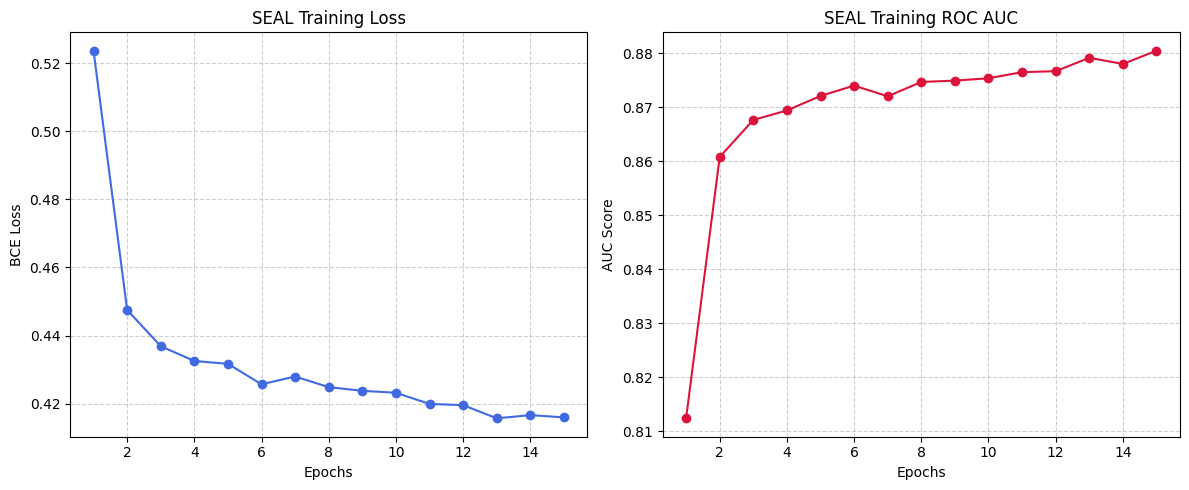

In [3]:
# --- 7. Final Metrics & Visualization ---

print("\n📊 Calculating Advanced Metrics on final Epoch...")
y_true = np.array(all_labels)
y_probs = np.array(all_preds)

# Calculate Precision-Recall AUC
pr_auc = average_precision_score(y_true, y_probs)

# Find best threshold for F1 Score
precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"--- Training Performance ---")
print(f"Final ROC AUC : {history['auc'][-1]:.4f}")
print(f"Final PR AUC  : {pr_auc:.4f}")
print(f"Best F1 Score : {best_f1:.4f} (at threshold {best_threshold:.4f})")

# Plotting the Learning Curves
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, 16), history['loss'], marker='o', color='royalblue')
plt.title('SEAL Training Loss')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: ROC AUC
plt.subplot(1, 2, 2)
plt.plot(range(1, 16), history['auc'], marker='o', color='crimson')
plt.title('SEAL Training ROC AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC Score')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()